In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

/home/ecastro/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Propiedades termofísicas

Para las simulaciones se seleccionan propiedades termofísicas que corresponden a un acero 4140.

<center>

| %C | %Mn | %Si | %Cr | %Mo | %Fe |
|----|-----|-----|-----|-----|-----|
| 0.4 | 0.9 | 0.25 | 1.0 | 0.20 | bal. |

</center>


Las propiedades que se grafican debajo fueron calculadas con ayuda del software Jmat Pro v10.2. y la base de datos "General Steels".

Para simulaciones de ciclos de calentamiento - enfriamiento de una geometría compleja con openFOAM v13, se consideran los casos con propiedades termofísicas variables, y con propiedades termofísicas constantes (valor promedio), con el fin de compararlos.

In [2]:
k_T = np.genfromtxt(os.path.join('data','k4140.csv'), skip_header=1)
rho_T = np.genfromtxt(os.path.join('data', 'rho4140.csv'), skip_header=1)
cp_T = np.genfromtxt(os.path.join('data', 'cp4140.csv'), skip_header=1)

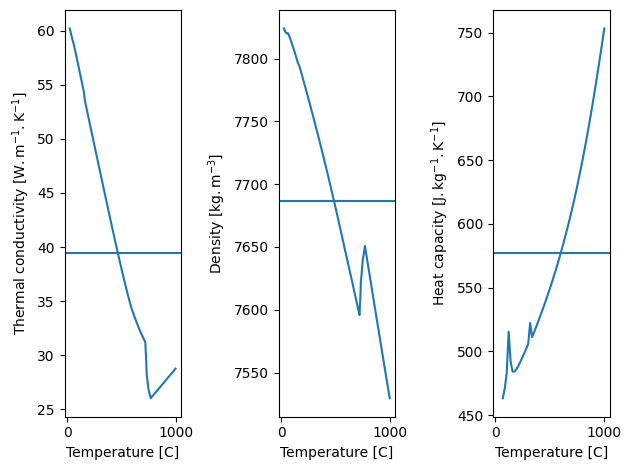

In [3]:
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, sharex=True)

# thermal conductivity
ax0.plot(k_T[:,0], k_T[:,1])
ax0.axhline(np.mean(k_T[:,1]))
ax0.set_xlabel("Temperature [C]")
ax0.set_ylabel(r"Thermal conductivity $[\mathrm{W.m^{-1}.K^{-1}}]$")

# density
ax1.plot(rho_T[:,0], rho_T[:,1])
ax1.axhline(np.mean(rho_T[:,1]))
ax1.set_xlabel("Temperature [C]")
ax1.set_ylabel(r"Density $[\mathrm{kg.m^{-3}}]$")

# heat capacity
ax2.plot(cp_T[:,0], cp_T[:,1])
ax2.axhline(np.mean(cp_T[:,1]))
ax2.set_xlabel("Temperature [C]")
ax2.set_ylabel(r"Heat capacity $[\mathrm{J.kg^{-1}.K^{-1}}]$")

fig.tight_layout()
plt.show()

# Condiciones de temple

Los valores típicos utilizados en las simulaciones se muestran en la Tabla debajo, y fueron tomados de:

    D.R. Poirier, G.H. Geiger (2016)
    Transport Phenomena in Materials Processing
    Springer International Publisher, Switzerland.
    p. 264.



<center>

| Quench media | H, $\mathrm{[m^{-1}]}$ | h, $\mathrm{[W.m^{-2}.K^{-1}]}$ |
|---------------|:---:|:-----:|
| Oil, no agitation | 7.9 | 270 |
| Oil, moderate agitation | 13.8 | 480 |
| Oil, good agitation | 19.7 | 680 |
| Oil, violent agitation | 27.6 | 970 |
| Water, no agitation | 39.4 | 1400 |
| Water, strong agitation | 59.0 | 2000 |
| Brine, no agitation | 78.7 | 2700 |
| Brine, violent agitation | 196 | 6800 |

</center>

# Ciclos térmicos

## Ciclo 1

La simulación del Ciclo Térmico 1 está en las carpetas `cycle1`, `cycle1c`

- El calentamiento y empape se realiza en un horno a $950$ $\mathrm{^{\circ}C}$, por $6$ minutos.
- Translado de la pieza entre horno y medio de temple, 30 segundos.
- Temple en un agua sin agitar, $h=1400$ $\mathrm{[W.m^{-2}.K^{-1}]}$.

In [4]:
cycle = "cycle1"
fileAvg = os.path.join(cycle, "postProcessing", "averageT", "0", "volFieldValue.dat")
fileMin = os.path.join(cycle, "postProcessing", "minT", "0", "volFieldValue.dat")
fileMax = os.path.join(cycle, "postProcessing", "maxT", "0", "volFieldValue.dat")

time1 = np.genfromtxt(fileAvg, delimiter="\t", usecols=0)
Tavg1 = np.genfromtxt(fileAvg, delimiter="\t", usecols=1) - 273.15
Tmin1 = np.genfromtxt(fileMin, delimiter="\t", usecols=1) - 273.15
Tmax1 = np.genfromtxt(fileMax, delimiter="\t", usecols=1) - 273.15


In [5]:
cycle = "cycle1c"
fileAvg = os.path.join(cycle, "postProcessing", "averageT", "0", "volFieldValue.dat")
fileMin = os.path.join(cycle, "postProcessing", "minT", "0", "volFieldValue.dat")
fileMax = os.path.join(cycle, "postProcessing", "maxT", "0", "volFieldValue.dat")

time1c = np.genfromtxt(fileAvg, delimiter="\t", usecols=0)
Tavg1c = np.genfromtxt(fileAvg, delimiter="\t", usecols=1) - 273.15
Tmin1c = np.genfromtxt(fileMin, delimiter="\t", usecols=1) - 273.15
Tmax1c = np.genfromtxt(fileMax, delimiter="\t", usecols=1) - 273.15

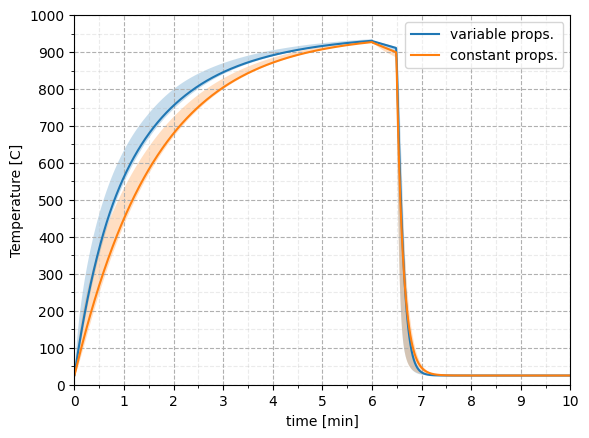

In [6]:
fig, ax = plt.subplots()

# ciclo 1
ax.plot(time1/60, Tavg1, c='C0', ls='-', label='variable props.')
ax.fill_between(time1/60, Tmin1, Tmax1, fc='C0', alpha=0.25)

# ciclo 2
ax.plot(time1c/60, Tavg1c, c='C1', ls='-', label='constant props.')
ax.fill_between(time1c/60, Tmin1c, Tmax1c, fc='C1', alpha=0.25)

# formato 
ax.set_xlabel("time [min]")
ax.set_xlim(0, 10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax.set_ylabel("Temperature [C]")
ax.set_ylim(0, 1000)
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

ax.grid(ls='--', which='major', alpha=1.0)
ax.grid(ls='--', which='minor', alpha=0.25)
ax.legend()

plt.show()

## Ciclo 2

La simulación del Ciclo Térmico 1 está en las carpetas `cycle2`, `cycle2c`

- El calentamiento y empape se realiza en un horno a $950$ $\mathrm{^{\circ}C}$, por $6$ minutos.
- Translado de la pieza entre horno y medio de temple, 30 segundos.
- Temple en un aceite sin agitar, $h=270$ $\mathrm{[W.m^{-2}.K^{-1}]}$.

In [7]:
cycle = "cycle2"
fileAvg = os.path.join(cycle, "postProcessing", "averageT", "0", "volFieldValue.dat")
fileMin = os.path.join(cycle, "postProcessing", "minT", "0", "volFieldValue.dat")
fileMax = os.path.join(cycle, "postProcessing", "maxT", "0", "volFieldValue.dat")

time2 = np.genfromtxt(fileAvg, delimiter="\t", usecols=0)
Tavg2 = np.genfromtxt(fileAvg, delimiter="\t", usecols=1) - 273.15
Tmin2 = np.genfromtxt(fileMin, delimiter="\t", usecols=1) - 273.15
Tmax2 = np.genfromtxt(fileMax, delimiter="\t", usecols=1) - 273.15


In [8]:
cycle = "cycle2c"
fileAvg = os.path.join(cycle, "postProcessing", "averageT", "0", "volFieldValue.dat")
fileMin = os.path.join(cycle, "postProcessing", "minT", "0", "volFieldValue.dat")
fileMax = os.path.join(cycle, "postProcessing", "maxT", "0", "volFieldValue.dat")

time2c = np.genfromtxt(fileAvg, delimiter="\t", usecols=0)
Tavg2c = np.genfromtxt(fileAvg, delimiter="\t", usecols=1) - 273.15
Tmin2c = np.genfromtxt(fileMin, delimiter="\t", usecols=1) - 273.15
Tmax2c = np.genfromtxt(fileMax, delimiter="\t", usecols=1) - 273.15

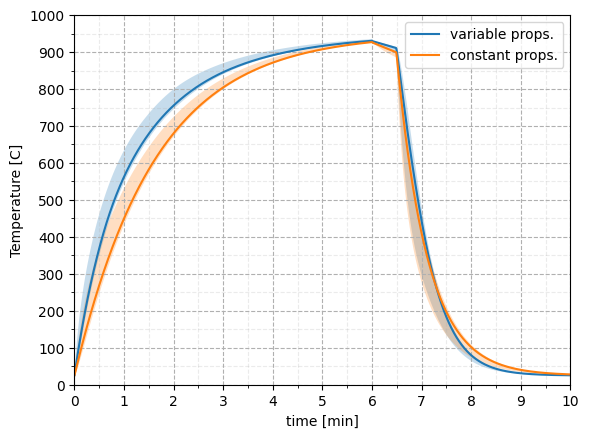

In [9]:
fig, ax = plt.subplots()

# ciclo 1
ax.plot(time2/60, Tavg2, c='C0', ls='-', label='variable props.')
ax.fill_between(time2/60, Tmin2, Tmax2, fc='C0', alpha=0.25)

# ciclo 2
ax.plot(time2c/60, Tavg2c, c='C1', ls='-', label='constant props.')
ax.fill_between(time2c/60, Tmin2c, Tmax2c, fc='C1', alpha=0.25)

# formato 
ax.set_xlabel("time [min]")
ax.set_xlim(0, 10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax.set_ylabel("Temperature [C]")
ax.set_ylim(0, 1000)
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

ax.grid(ls='--', which='major', alpha=1.0)
ax.grid(ls='--', which='minor', alpha=0.25)
ax.legend()

plt.show()

# Comparación gráfica de ciclos térmicos

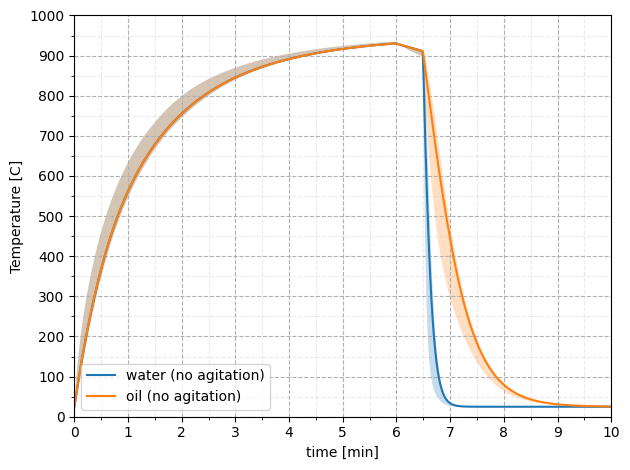

In [11]:
fig, ax = plt.subplots()

# ciclo 1
ax.plot(time1/60, Tavg1, c='C0', ls='-', label='water (no agitation)')
ax.fill_between(time1/60, Tmin1, Tmax1, fc='C0', alpha=0.25)

# ciclo 2
ax.plot(time2/60, Tavg2, c='C1', ls='-', label='oil (no agitation)')
ax.fill_between(time2/60, Tmin2, Tmax2, fc='C1', alpha=0.25)

# formato 
ax.set_xlabel("time [min]")
ax.set_xlim(0, 10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax.set_ylabel("Temperature [C]")
ax.set_ylim(0, 1000)
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

ax.grid(ls='--', which='major', alpha=1.0)
ax.grid(ls='--', which='minor', alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join("data", "thermalcycle.png"))
plt.show()